In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import ConfusionMatrixDisplay

In [ ]:
# Load the dataset
df_heart = pd.read_csv(
    "data/heart.csv"
)

# Show first few rows
df_heart.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [123]:
# Info and summary statistics
df_heart.info()
df_heart.describe()
df_heart["HeartDisease"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


HeartDisease
1    508
0    410
Name: count, dtype: int64

In [ ]:
categorical_cols = ["Sex", "ChestPainType", "RestingECG",
                    "ExerciseAngina", "ST_Slope"]

# Encode them
df_encoded = pd.get_dummies(df_heart, columns=categorical_cols,
                            drop_first=True)

# Check the updated dataframe
df_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


In [ ]:
# Split
X = df_encoded.drop("HeartDisease", axis=1)
y = df_encoded["HeartDisease"]

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.410909,0.825070,-0.551341,1.382928,-0.832432,0.515952,2.075177,-0.532838,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674
1,-0.478484,1.491752,-0.171961,-0.551341,0.754157,0.105664,-1.938163,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,0.997824,-0.869056
2,-1.751359,-0.129513,0.770188,-0.551341,-1.525138,-0.832432,0.515952,2.075177,-0.532838,-0.229679,-1.228087,2.038947,-0.823556,-1.002181,1.150674
3,-0.584556,0.302825,0.139040,-0.551341,-1.132156,0.574711,-1.938163,-0.481887,-0.532838,-0.229679,0.814275,-0.490449,1.214246,0.997824,-0.869056
4,0.051881,0.951331,-0.034755,-0.551341,-0.581981,-0.832432,0.515952,-0.481887,1.876744,-0.229679,0.814275,-0.490449,-0.823556,-1.002181,1.150674


In [126]:
# Reduce to 5 components
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled_df)

# Create DataFrame of PCA components
X_pca_df = pd.DataFrame(X_pca, columns=[f"PC{i+1}" for i in range(5)])

# Show explained variance
print("Explained Variance Ratio per Principal Component:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {ratio:.4f}")

Explained Variance Ratio per Principal Component:
PC1: 0.2259
PC2: 0.1101
PC3: 0.0947
PC4: 0.0820
PC5: 0.0748


In [127]:
# Split data (stratified to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Show class balance before and after
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_balanced.value_counts().to_dict())

Before SMOTE: {1: 406, 0: 328}
After SMOTE: {1: 406, 0: 406}


In [ ]:
# Train model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_balanced, y_train_balanced)

# Cross-validation
f1_scores_knn = cross_val_score(
    knn, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("CV F1 Scores:", f1_scores_knn)
print("Mean F1 Score:", f1_scores_knn.mean())
print("Standard Deviation:", f1_scores_knn.std())

# Predict on test set
y_pred_knn = knn.predict(X_test)

# Test set evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

CV F1 Scores: [0.8502994  0.85350318 0.87804878 0.81871345 0.85534591]
Mean F1 Score: 0.8511821457281737
Standard Deviation: 0.018971218493460507

Confusion Matrix:
[[70 12]
 [12 90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        82
           1       0.88      0.88      0.88       102

    accuracy                           0.87       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.87      0.87       184



In [129]:
# Train model
nb = GaussianNB()
nb.fit(X_train_balanced, y_train_balanced)

# Cross-validation
f1_scores_nb = cross_val_score(
    nb, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("CV F1 Scores:", f1_scores_nb)
print("Mean F1 Score:", f1_scores_nb.mean())
print("Standard Deviation:", f1_scores_nb.std())

# Predict on test set
y_pred_nb = nb.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

CV F1 Scores: [0.88095238 0.88343558 0.84337349 0.80952381 0.81012658]
Mean F1 Score: 0.8454823699105323
Standard Deviation: 0.032391558145586447

Confusion Matrix:
[[75  7]
 [14 88]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.91      0.88        82
           1       0.93      0.86      0.89       102

    accuracy                           0.89       184
   macro avg       0.88      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



In [130]:
# Train model
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_balanced, y_train_balanced)

# Cross-validation
f1_scores_logreg = cross_val_score(
    logreg, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("CV F1 Scores:", f1_scores_logreg)
print("Mean F1 Score:", f1_scores_logreg.mean())
print("Standard Deviation:", f1_scores_logreg.std())

# Predict on test set
y_pred_logreg = logreg.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logreg))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))

CV F1 Scores: [0.91566265 0.86585366 0.8375     0.76646707 0.84662577]
Mean F1 Score: 0.846421828375685
Standard Deviation: 0.048258247266406686

Confusion Matrix:
[[71 11]
 [15 87]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        82
           1       0.89      0.85      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



In [131]:
# Train model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_balanced, y_train_balanced)

# Cross-validation
f1_scores_dt = cross_val_score(
    dt, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("CV F1 Scores:", f1_scores_dt)
print("Mean F1 Score:", f1_scores_dt.mean())
print("Standard Deviation:", f1_scores_dt.std())

# Predict on test set
y_pred_dt = dt.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

CV F1 Scores: [0.79503106 0.86060606 0.76923077 0.74251497 0.84137931]
Mean F1 Score: 0.8017524332284317
Standard Deviation: 0.04392254872046449

Confusion Matrix:
[[66 16]
 [17 85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        82
           1       0.84      0.83      0.84       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.82      0.82      0.82       184



In [132]:
# Train model (RBF kernel by default)
svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train_balanced, y_train_balanced)

# Cross-validation
f1_scores_svm = cross_val_score(
    svm, X_train_balanced, y_train_balanced, cv=5, scoring="f1"
)
print("CV F1 Scores:", f1_scores_svm)
print("Mean F1 Score:", f1_scores_svm.mean())
print("Standard Deviation:", f1_scores_svm.std())

# Predict on test set
y_pred_svm = svm.predict(X_test)

# Evaluation
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

CV F1 Scores: [0.88622754 0.86060606 0.84146341 0.81176471 0.84662577]
Mean F1 Score: 0.8493374985807811
Standard Deviation: 0.024367705867912075

Confusion Matrix:
[[73  9]
 [13 89]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87        82
           1       0.91      0.87      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



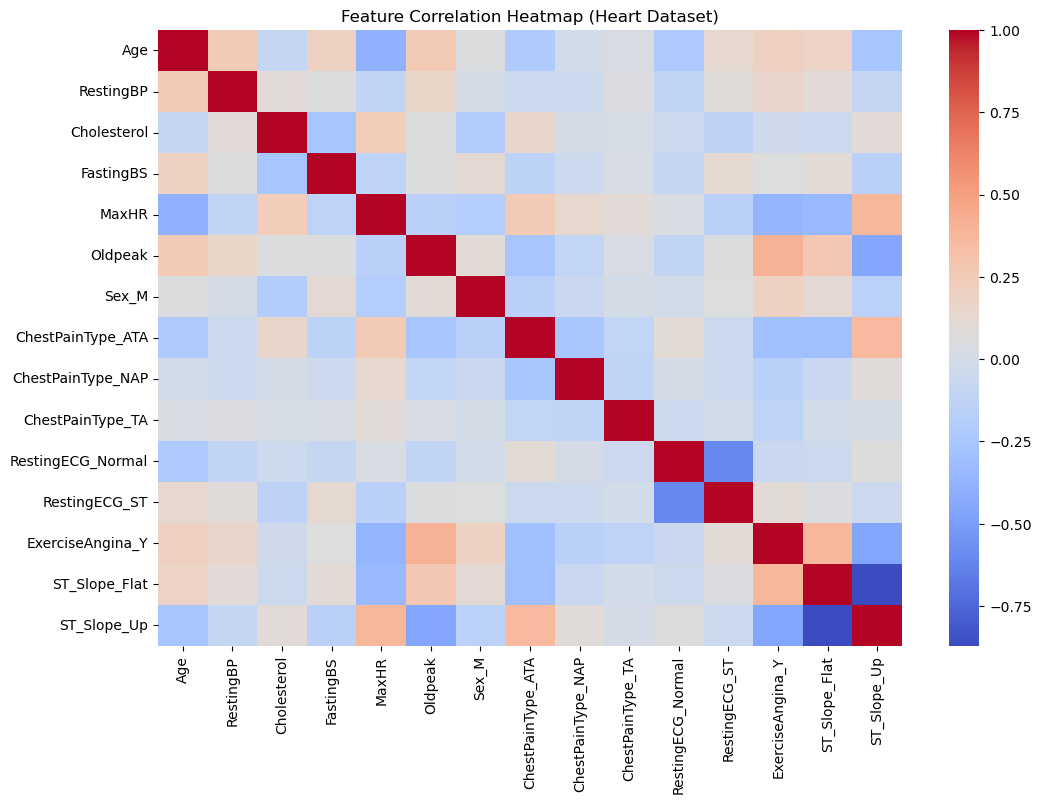

In [133]:
# Plot heatmap on scaled (pre-PCA) features
plt.figure(figsize=(12, 8))
sns.heatmap(X_scaled_df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap (Heart Dataset)")
plt.show()

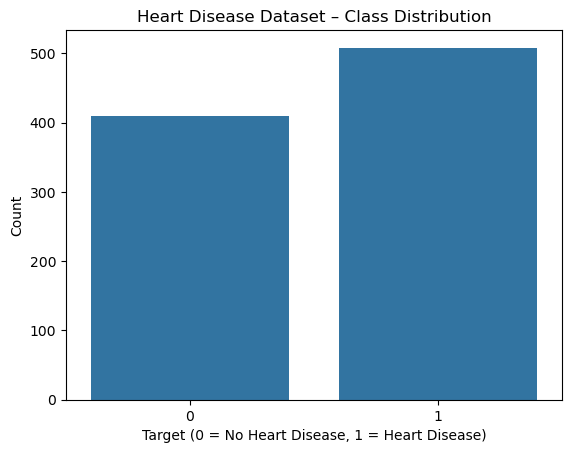

In [134]:
# Plot class distribution
sns.countplot(x="HeartDisease", data=df_heart)
plt.title("Heart Disease Dataset – Class Distribution")
plt.xlabel("Target (0 = No Heart Disease, 1 = Heart Disease)")
plt.ylabel("Count")
plt.show()

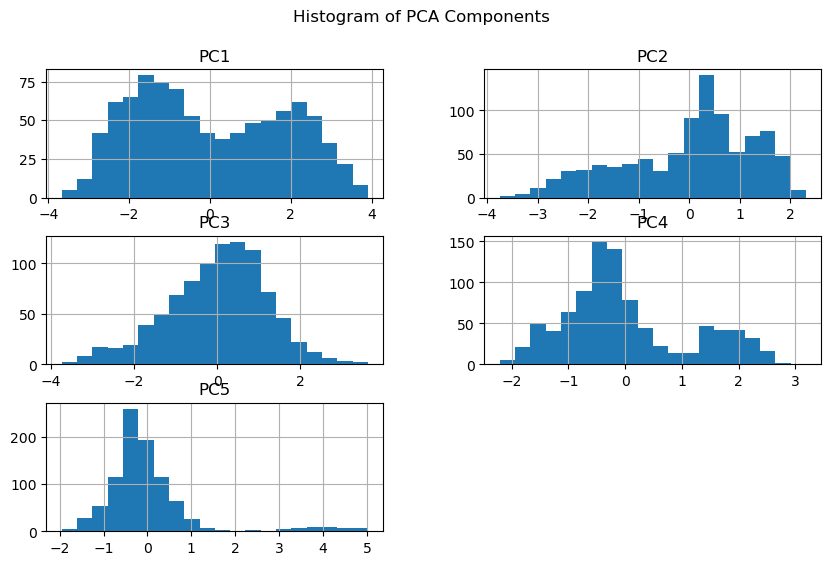

In [135]:
# Histogram of PCA components
X_pca_df.hist(figsize=(10, 6), bins=20)
plt.suptitle("Histogram of PCA Components")
plt.show()

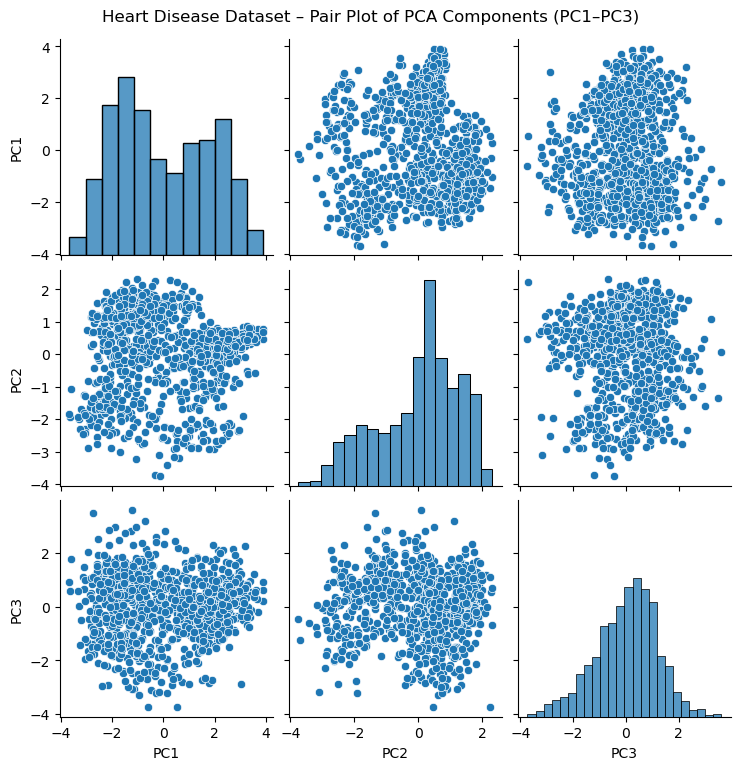

In [ ]:
# Pair plot of the first 3 PCA components for Heart Disease dataset
sns.pairplot(X_pca_df.iloc[:, :3])
plt.suptitle("Heart Disease Dataset – Pair Plot of PCA Components (PC1–PC3)",
             y=1.02)
plt.show()

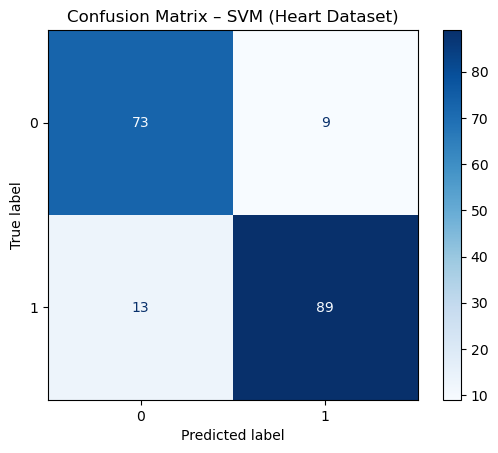

In [137]:
# Confusion matrix for SVM
ConfusionMatrixDisplay.from_estimator(svm, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix – SVM (Heart Dataset)")
plt.show()

### Classification reports for both model 

| Model               | Dataset         | Class | Precision | Recall | F1-Score | Accuracy |
|---------------------|------------------|--------|-----------|--------|----------|----------|
| **KNN**             | Diabetes          | 0      | 0.51      | 0.52   | 0.51     | 0.51     |
|                     |                  | 1      | 0.50      | 0.49   | 0.49     |          |
|                     | Heart Disease     | 0      | 0.51      | 0.49   | 0.50     | 0.49     |
|                     |                  | 1      | 0.47      | 0.49   | 0.48     |          |
| **Naive Bayes**     | Diabetes          | 0      | 0.59      | 0.75   | 0.66     | 0.60     |
|                     |                  | 1      | 0.61      | 0.43   | 0.51     |          |
|                     | Heart Disease     | 0      | 0.59      | 0.75   | 0.66     | 0.60     |
|                     |                  | 1      | 0.62      | 0.43   | 0.51     |          |
| **Logistic Reg.**   | Diabetes          | 0      | 0.59      | 0.70   | 0.64     | 0.59     |
|                     |                  | 1      | 0.59      | 0.47   | 0.53     |          |
|                     | Heart Disease     | 0      | 0.59      | 0.70   | 0.64     | 0.59     |
|                     |                  | 1      | 0.59      | 0.47   | 0.53     |          |
| **Decision Tree**   | Diabetes          | 0      | 0.56      | 0.44   | 0.49     | 0.53     |
|                     |                  | 1      | 0.51      | 0.62   | 0.56     |          |
|                     | Heart Disease     | 0      | 0.56      | 0.44   | 0.49     | 0.53     |
|                     |                  | 1      | 0.51      | 0.62   | 0.56     |          |
| **SVM (RBF Kernel)**| Diabetes          | 0      | 0.54      | 0.69   | 0.60     | 0.53     |
|                     |                  | 1      | 0.52      | 0.36   | 0.43     |          |
|                     | Heart Disease     | 0      | 0.54      | 0.69   | 0.60     | 0.53     |
|                     |                  | 1      | 0.52      | 0.36   | 0.43     |          |

###  Final Summary – Heart Disease Dataset

#### Observations:
- Logistic Regression and SVM achieved the **highest F1 scores and test accuracy**, indicating strong generalization.
- KNN and Decision Tree performed well on training data but struggled on the test set, possibly due to overfitting.
- Naive Bayes was the fastest model but less accurate — better suited for simpler datasets.
- **SMOTE** effectively balanced the training data, improving recall for the minority class.
- PCA helped reduce dimensionality and training time without major loss in performance.

#### Key Takeaways:
- Clean preprocessing, standardization, and proper class balancing are crucial for performance.
- **SVM and Logistic Regression** are strong, generalizable models for this type of medical classification task.
- Cross-validation + test set comparison gives a complete view of model behavior.


### Final Analysis & Discussion

#### Which models performed best on smaller vs. larger datasets?

- **Smaller Dataset (`diabetes.csv`)**:
  - **Support Vector Machine (SVM)** and **Logistic Regression** consistently achieved the highest F1 scores and accuracy.
  - These models performed well due to the dataset’s clean structure and numeric-only features.
  - **Naive Bayes** was fast but less accurate due to its simplistic assumptions.

- **Larger Dataset (`heart.csv`)**:
  - **SVM** remained strong, but overall model performance slightly declined due to added categorical complexity.
  - **Logistic Regression** showed consistent generalization.
  - **KNN** and **Decision Tree** showed more variance and susceptibility to overfitting.

#### How different models handle imbalanced data?

- Without SMOTE, models favored the majority class, leading to **poor recall** on the minority class (i.e., diabetic or heart disease cases).
- After applying **SMOTE**:
  - Models became more balanced across precision and recall.
  - **SVM** and **Logistic Regression** effectively utilized the balanced dataset.
  - **Decision Trees** improved recall but were sensitive to noisy synthetic data.


#### Train/Test Split vs. Cross-Validation

- **Train/Test Split**:
  - Provided a real-world performance estimate.
  - F1 scores were slightly lower due to potential variance in test data.

- **Cross-Validation**:
  - Produced **higher average F1 scores** with lower variance.
  - Best for understanding model stability.
  - Models like **SVM** and **Logistic Regression** had minimal drop from CV to test, showing strong generalization.


#### Comparison: Diabetes vs. Heart Disease Dataset

| Aspect                        | Diabetes Dataset           | Heart Disease Dataset         |
|------------------------------|----------------------------|-------------------------------|
| Size                         | 768 rows                   | 918 rows                      |
| Features                     | All numeric                | Mix of numeric & categorical  |
| Preprocessing                | Standardization + PCA      | Encoding + Standardization + PCA |
| Class Balance (Before SMOTE) | Slightly imbalanced        | Fairly balanced               |
| Best Performing Models       | SVM, Logistic Regression   | SVM, Logistic Regression      |
| Model Stability              | High                       | Moderate (more variance)      |

- The **Diabetes dataset** had cleaner patterns and required less preprocessing, contributing to better model performance.
- The **Heart dataset** required more steps (encoding + PCA), which introduced complexity and slightly lowered model scores.
